<a href="https://colab.research.google.com/github/murtazaarsh7/Deep_learning/blob/main/Droput_layers_ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense,Dropout
from keras import Sequential
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from keras.optimizers import Adam


In [ ]:
x_train=np.linspace(-1,1,20)

In [ ]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  ,
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475,
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [ ]:
x_test=np.linspace(-1,1,20)

In [ ]:
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

In [ ]:
import matplotlib.pyplot as plt

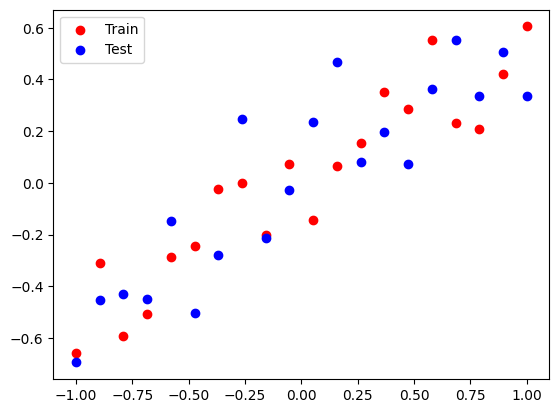

In [ ]:
plt.scatter(x_train, y_train, c='red', label='Train')
plt.scatter(x_test, y_test, c='blue', label='Test')
plt.legend()
plt.show()

regression model

In [ ]:
model=Sequential()

In [ ]:
model.add(Dense(128,input_dim=1,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='linear'))
adam=Adam(learning_rate=0.01)
model.compile(loss='mse',optimizer=adam,metrics=['accuracy'])
history=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=500,verbose=False)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# evaluate the model
_, train_mse = model.evaluate(x_train, y_train, verbose=0)
_, test_mse = model.evaluate(x_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.0, Test: 0.0


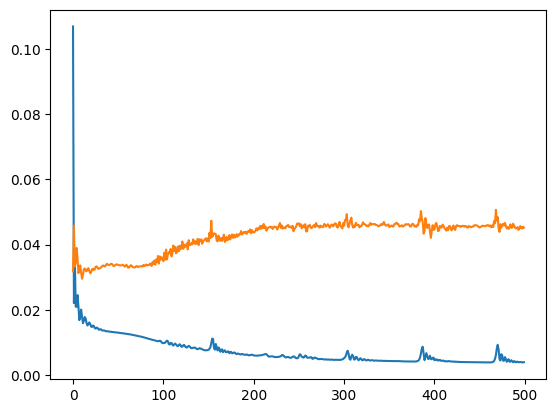

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [ ]:
y_pred=model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


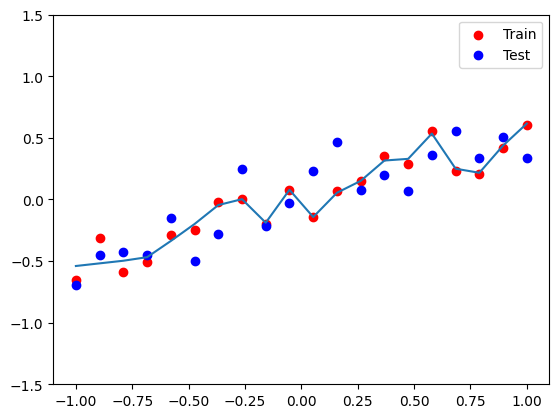

In [ ]:
plt.figure()
plt.scatter(x_train, y_train, c='red', label='Train')
plt.scatter(x_test, y_test, c='blue', label='Test')
plt.plot(x_test, y_pred)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

model is overfitting


# *** Droput Model ***


In [39]:
model2=Sequential()

In [46]:
model2.add(Dense(128,input_dim=1,activation='relu'))
model2.add(Dense(128,activation='relu'))
model2.add(Dropout(0.5))
model2.add(Dense(1,activation='linear'))
adam=Adam(learning_rate=0.01)
model2.compile(loss='mse',optimizer=adam,metrics=['accuracy'])
history2=model2.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=100,verbose=True)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.0000e+00 - loss: 0.1310 - val_accuracy: 0.0000e+00 - val_loss: 0.0640
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.0000e+00 - loss: 0.0419 - val_accuracy: 0.0000e+00 - val_loss: 0.0658
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.0000e+00 - loss: 0.0460 - val_accuracy: 0.0000e+00 - val_loss: 0.0544
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.0000e+00 - loss: 0.0358 - val_accuracy: 0.0000e+00 - val_loss: 0.0506
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.0000e+00 - loss: 0.0320 - val_accuracy: 0.0000e+00 - val_loss: 0.0445
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.0000e+00 - loss: 0.0329 - val_accuracy: 0.0000e+00 - val_loss: 0.0457
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.0000e+00 - loss: 0.0328 - val_accuracy: 0.0000e+00 - val_loss: 0.0487
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accurac

In [41]:
# evaluate the model
_, train_mse = model.evaluate(x_train, y_train, verbose=0)
_, test_mse = model.evaluate(x_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.0, Test: 0.0


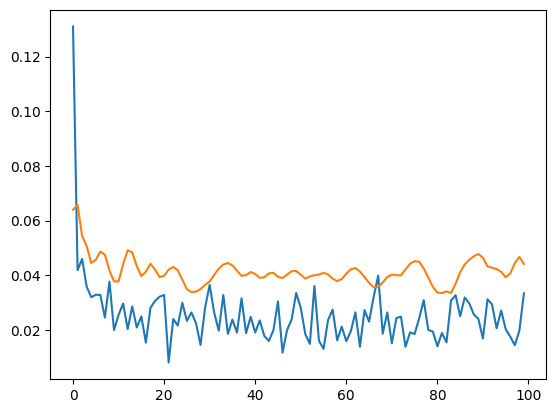

In [47]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

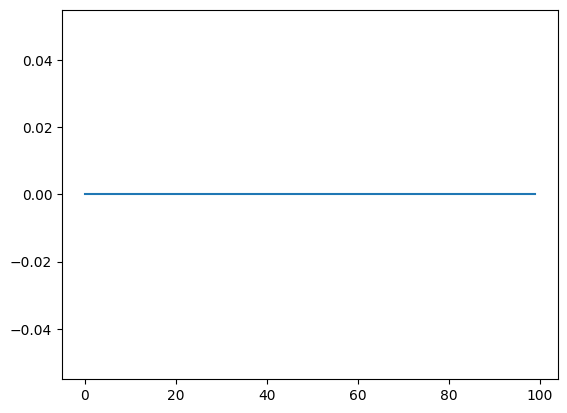

In [48]:
plt.plot(history2.history['accuracy'])

In [49]:
y_pred2=model2.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


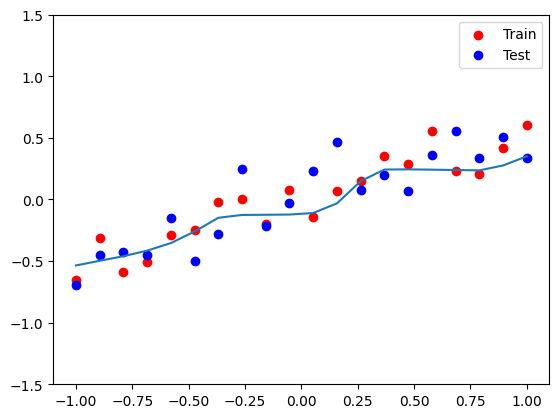

In [50]:
plt.figure()
plt.scatter(x_train, y_train, c='red', label='Train')
plt.scatter(x_test, y_test, c='blue', label='Test')
plt.plot(x_test, y_pred2)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()